# A matrix-free inverse-distance QJet for three-dimensional surfaces

This notebook explains and executes the production three-dimensional
`ProductionRieszQJet`.  The method evaluates

$$
(Q_{p,h}f)_i
=\sum_{j\ne i} w_j\frac{f_i-f_j}{\lVert X_i-X_j\rVert^p},
\qquad X_i\in\mathbb R^3,
$$

without forming or storing the dense pair matrix.  It replaces separated
pair blocks by fixed-order Cartesian source jets, evaluates both block
orientations by an exact transpose, and keeps unresolved terminal blocks
exact.  Runtime guards raise an exception instead of entering an
unbudgeted quadratic fallback.

The notebook uses the repository's production implementation.  Its own
geometry, tables, and SVG diagrams use Python scalar arithmetic only; it
does not import NumPy, SciPy, or an external fast multipole package.

## Statements established here

1. **Discrete structure.**  $Q_{p,h}$ kills constants, is self-adjoint in
   the weighted inner product, and has a nonnegative Dirichlet form.
2. **Geometry.**  Under $X\mapsto aX$ and surface weights
   $w\mapsto a^2w$, $Q_{p,h}\mapsto a^{2-p}Q_{p,h}$.  Thus the
   inverse-square operator is scale invariant and the inverse-cube
   operator has the first-order scaling of a DtN map.
3. **Continuum principal part.**  On a smooth two-dimensional surface,
   $Q_{3,h}/(2\pi)$ has principal symbol $|\xi|_g$, the principal
   symbol of the Laplace Dirichlet-to-Neumann map.
4. **Certified compression.**  The fair-split pair decomposition is an
   exact partition of unordered pairs.  Every separated block has a
   convergent Gegenbauer expansion with an explicit tail bound.
5. **Cost contract.**  For fixed dimension, tolerance, expansion cap, and
   leaf size, the production path stores $O(N)$ data and applies in
   $O(N\log N)$.  If its explicit work budgets are exceeded, it fails
   closed.  There is no dense or quadratic fallback.

The numerical comparisons below audit the **discrete graph operator**
against an isolated streamed pair sum.  They are not, by themselves, a
proof of continuum boundary-element convergence at polyhedral edges or
vertices.  Those singular channels are treated separately near the end.

In [1]:
import html
import json
import math
import sys
import time
from pathlib import Path

from IPython.display import HTML, SVG, display

ROOT = Path.cwd().resolve()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "inverse_shape").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("run this notebook inside the inverse-shape repository")

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from inverse_shape.riesz_near_linear import ProductionRieszQJet
from inverse_shape.arbitrary_surface import triangle_lumped_vertex_weights
from inverse_shape.testing.reference_pairwise import (
    reference_weighted_distance_graph,
)
from inverse_shape.polyhedral_kondratiev import (
    EdgeMellinPencil,
    MellinKondratievRepayment,
    MellinThreeJetChannel,
)

PI = math.pi
TAU = 2.0 * PI

def fmt(value, digits=3):
    value = float(value)
    if value == 0.0:
        return "0"
    if abs(value) < 1.0e-3 or abs(value) >= 1.0e4:
        return f"{value:.{digits}e}"
    return f"{value:.{digits}f}"

def show_table(headers, rows):
    head = "".join(f"<th>{html.escape(str(item))}</th>" for item in headers)
    body = "".join(
        "<tr>" + "".join(
            f"<td>{html.escape(str(item))}</td>" for item in row
        ) + "</tr>"
        for row in rows
    )
    display(HTML(
        "<table style='border-collapse:collapse;font-family:serif;font-size:13px'>"
        "<thead><tr style='border-bottom:1px solid #111'>" + head + "</tr></thead>"
        "<tbody>" + body + "</tbody></table>"
    ))

print("Repository root located.")
print("Backend:", ProductionRieszQJet.__name__)

Repository root located.
Backend: ProductionRieszQJet


## 1. Geometry before algebra

A target does not need to resolve every distant source individually.  If a
source cluster lies in $B(c,a)$, a target $x$ sees that cluster through
the dimensionless ratio

$$
\rho=\frac{a}{\lVert x-c\rVert}.
$$

For $\rho<1$, the entire cluster is represented by finitely many moments.
Close clusters are split until this analytic test passes or both clusters
are terminal leaves, in which case their few pairs are evaluated exactly.
The method therefore adapts the **representation**, not the global mesh.

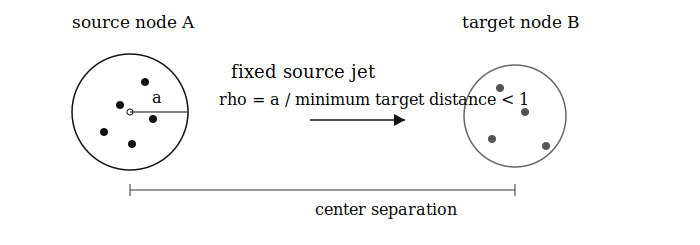

In [2]:
def separation_svg():
    source = [(120, 105), (145, 82), (153, 119), (104, 132), (132, 144)]
    target = [(500, 88), (525, 112), (492, 139), (546, 146)]
    circles = []
    for x, y in source:
        circles.append(f"<circle cx='{x}' cy='{y}' r='4' fill='#111'/>")
    for x, y in target:
        circles.append(f"<circle cx='{x}' cy='{y}' r='4' fill='#555'/>")
    return f'''
    <svg xmlns='http://www.w3.org/2000/svg' width='700' height='245' viewBox='0 0 700 245'>
      <rect width='700' height='245' fill='white'/>
      <circle cx='130' cy='112' r='58' fill='none' stroke='#111' stroke-width='1.5'/>
      <circle cx='515' cy='116' r='51' fill='none' stroke='#666' stroke-width='1.5'/>
      {''.join(circles)}
      <circle cx='130' cy='112' r='3' fill='white' stroke='#111'/>
      <line x1='130' y1='112' x2='188' y2='112' stroke='#111'/>
      <text x='152' y='103' font-family='serif' font-size='16'>a</text>
      <line x1='130' y1='190' x2='515' y2='190' stroke='#333'/>
      <line x1='130' y1='184' x2='130' y2='196' stroke='#333'/>
      <line x1='515' y1='184' x2='515' y2='196' stroke='#333'/>
      <text x='315' y='215' font-family='serif' font-size='16'>center separation</text>
      <text x='72' y='28' font-family='serif' font-size='17'>source node A</text>
      <text x='462' y='28' font-family='serif' font-size='17'>target node B</text>
      <text x='231' y='78' font-family='serif' font-size='18'>fixed source jet</text>
      <text x='219' y='105' font-family='serif' font-size='16'>rho = a / minimum target distance &lt; 1</text>
      <path d='M310 120 L405 120' stroke='#111' stroke-width='1.5'/>
      <path d='M405 120 L394 114 L394 126 Z' fill='#111'/>
    </svg>
    '''

display(SVG(separation_svg()))

## 2. The discrete operator

Let $K_{ij}=\lVert X_i-X_j\rVert^{-p}$ for $i\ne j$, with positive
quadrature weights $w_i$.  Define

$$
(Q_{p,h}f)_i=\sum_{j\ne i}w_jK_{ij}(f_i-f_j).
\tag{2.1}
$$

**Proposition 2.1 (nullspace, symmetry, and energy).**  For real or complex
vectors and the weighted inner product
$⟨f,g⟩_w=\sum_i w_i\overline{f_i}g_i$,

$$
Q_{p,h}{\bf1}=0,
\qquad
⟨f,Q_{p,h}g⟩_w=⟨Q_{p,h}f,g⟩_w,
$$

and

$$
⟨f,Q_{p,h}f⟩_w
=\sum_{i<j}w_iw_jK_{ij}|f_i-f_j|^2\ge0.
\tag{2.2}
$$

**Proof.**  The first identity is immediate from (2.1).  In the double sum
for the inner product, group the ordered terms $(i,j)$ and $(j,i)$.
Since $K_{ij}=K_{ji}$, their sum is
$w_iw_jK_{ij}(\overline{f_i}-\overline{f_j})(g_i-g_j)$.
Summing once over $i<j$ proves self-adjointness.  Setting $g=f$
gives (2.2).  No continuum approximation is used.  $□$

In [3]:
def sphere(latitude_count=8, longitude_count=12, scales=(1.0, 1.0, 1.0)):
    points, weights = [], []
    for latitude in range(latitude_count):
        theta = PI * (latitude + 0.5) / latitude_count
        st, ct = math.sin(theta), math.cos(theta)
        for longitude in range(longitude_count):
            phase = TAU * longitude / longitude_count
            points.append((
                scales[0] * st * math.cos(phase),
                scales[1] * st * math.sin(phase),
                scales[2] * ct,
            ))
            weights.append(st * PI / latitude_count * TAU / longitude_count)
    return tuple(points), tuple(weights)

def torus(major_count=10, minor_count=6):
    points, weights = [], []
    major_radius, minor_radius = 1.4, 0.35
    for major in range(major_count):
        u = TAU * major / major_count
        for minor in range(minor_count):
            v = TAU * minor / minor_count
            radial = major_radius + minor_radius * math.cos(v)
            points.append((
                radial * math.cos(u), radial * math.sin(u),
                minor_radius * math.sin(v),
            ))
            weights.append(
                minor_radius * radial * TAU / major_count * TAU / minor_count
            )
    return tuple(points), tuple(weights)

def folded_sheet(nx=10, ny=6):
    points, weights = [], []
    for ix in range(nx):
        x = -1.0 + 2.0 * (ix + 0.5) / nx
        for iy in range(ny):
            y = -0.8 + 1.6 * (iy + 0.5) / ny
            z = 0.35 * math.sin(1.7 * x) + 0.18 * math.sin(2.3 * y + 0.4 * x)
            points.append((x, y, z))
            weights.append(3.2 / (nx * ny))
    return tuple(points), tuple(weights)

def mobius(around=12, across=5):
    points, weights = [], []
    half_width = 0.28
    for along in range(around):
        u = TAU * along / around
        for transverse in range(across):
            v = half_width * (2.0 * (transverse + 0.5) / across - 1.0)
            radial = 1.2 + v * math.cos(0.5 * u)
            points.append((radial * math.cos(u), radial * math.sin(u), v * math.sin(0.5 * u)))
            weights.append(2.0 * half_width * TAU * 1.2 / (around * across))
    return tuple(points), tuple(weights)

def star_surface():
    points, weights = sphere(8, 12)
    output = []
    for x, y, z in points:
        radial = math.sqrt(max(x * x + y * y, 0.0))
        scale = 1.0 + 0.16 * (4.0 * z * z - 1.0) * radial
        output.append((scale * x, scale * y, scale * z))
    return tuple(output), weights

def faceted_octahedron(refinements=2):
    vertices = [
        (1.0, 0.0, 0.0), (-1.0, 0.0, 0.0),
        (0.0, 1.0, 0.0), (0.0, -1.0, 0.0),
        (0.0, 0.0, 1.0), (0.0, 0.0, -1.0),
    ]
    faces = [
        (0, 2, 4), (2, 1, 4), (1, 3, 4), (3, 0, 4),
        (2, 0, 5), (1, 2, 5), (3, 1, 5), (0, 3, 5),
    ]
    for _ in range(refinements):
        midpoint_cache = {}

        def midpoint(left, right):
            edge = (min(left, right), max(left, right))
            if edge not in midpoint_cache:
                a, b = vertices[left], vertices[right]
                midpoint_cache[edge] = len(vertices)
                vertices.append(tuple(0.5 * (a[k] + b[k]) for k in range(3)))
            return midpoint_cache[edge]

        refined = []
        for a, b, c in faces:
            ab, bc, ca = midpoint(a, b), midpoint(b, c), midpoint(c, a)
            refined.extend(((a, ab, ca), (ab, b, bc), (ca, bc, c), (ab, bc, ca)))
        faces = refined
    points = tuple(vertices)
    triangles = tuple(faces)
    return points, triangle_lumped_vertex_weights(points, triangles)

def field(points):
    return tuple(x + 0.2 * y - 0.1 * z * z + 0.03j * (y + z) for x, y, z in points)

points, weights = torus()
f = tuple(x - 0.1 * z for x, _y, z in points)
g = tuple(y + 0.2 * z for _x, y, z in points)
q = ProductionRieszQJet(points, weights, kernel_power=2.0, tolerance=3e-13, maximum_order=16, leaf_size=4)
qf, qg = q.apply(f), q.apply(g)
lhs = sum(weights[i] * f[i] * complex(qg[i]).real for i in range(len(points)))
rhs = sum(weights[i] * complex(qf[i]).real * g[i] for i in range(len(points)))
energy = sum(weights[i] * f[i] * complex(qf[i]).real for i in range(len(points)))
show_table(
    ["invariant", "measured value"],
    [
        ["constant residual", fmt(q.constant_residual())],
        ["weighted adjoint residual", fmt(abs(lhs - rhs) / max(1.0, abs(lhs), abs(rhs)))],
        ["Dirichlet energy", fmt(energy)],
    ],
)
assert q.constant_residual() == 0.0
assert abs(lhs - rhs) / max(1.0, abs(lhs), abs(rhs)) < 5e-13
assert energy >= -5e-13

invariant,measured value
constant residual,0
weighted adjoint residual,3.164e-15
Dirichlet energy,84.494


## 3. Scaling and the two kernel powers

**Proposition 3.1 (surface scaling).**  If $X_i'=aX_i$ and the weights
represent surface area, so $w_i'=a^2w_i$, then

$$
Q'_{p,h}=a^{2-p}Q_{p,h}.
\tag{3.1}
$$

**Proof.**  Each summand acquires $a^2$ from its weight and $a^{-p}$
from the kernel.  The field difference is unchanged.  $□$

Consequently:

- $p=2$: $Q_{2,h}$ is scale invariant.  This is the three-dimensional
  inverse-square/discriminant graph used for geometric bookkeeping.
- $p=3$: $Q_{3,h}$ scales as $a^{-1}$, exactly as a first-order
  surface operator and the Laplace DtN map.

In [4]:
base_points, base_weights = mobius()
values = tuple(complex(index / len(base_points), (-1) ** index * 0.03) for index in range(len(base_points)))
scale = 2.3
scaled_points = tuple(tuple(scale * coordinate for coordinate in point) for point in base_points)
scaled_weights = tuple(scale * scale * weight for weight in base_weights)
scale_rows = []
for power in (2.0, 3.0):
    unit = ProductionRieszQJet(base_points, base_weights, kernel_power=power, tolerance=3e-13, maximum_order=16, leaf_size=4).apply(values)
    enlarged = ProductionRieszQJet(scaled_points, scaled_weights, kernel_power=power, tolerance=3e-13, maximum_order=16, leaf_size=4).apply(values)
    expected = scale ** (2.0 - power)
    residual = max(abs(complex(enlarged[i]) - expected * complex(unit[i])) for i in range(len(unit)))
    denominator = max(1.0, max(abs(complex(value)) for value in unit))
    scale_rows.append([int(power), fmt(expected), fmt(residual / denominator)])
show_table(["p", "predicted multiplier", "relative residual"], scale_rows)
assert max(float(row[-1]) for row in scale_rows) < 5e-12

p,predicted multiplier,relative residual
2,1.000,4.100e-16
3,0.435,6.649e-16


## 4. Why inverse square appears: the Euclidean discriminant

The scalar inverse-square kernel is not the full coordinate Hessian of a
log distance on an arbitrary surface.  The exact general identity in three
dimensions is the **trace** identity

$$
\Delta_x\log\lVert x-y\rVert^2=\frac{2}{\lVert x-y\rVert^2},
\qquad x\ne y.
\tag{4.1}
$$

**Proof.**  Put $r=\lVert x-y\rVert$.  For a radial function in
$ℝ^3$, $Δu=u''(r)+2u'(r)/r$.  With $u(r)=2\log r$,
$u'=2/r$ and $u''=-2/r^2$, hence $Δu=2/r^2$.  $□$

More directly, for any source residues $r_j$ define the peeled potential

$$
L_r(i)=\sum_{j\ne i}r_j\log\lVert X_i-X_j\rVert^2.
$$

Then

$$
S_r(i):=\frac12\Delta_{X_i}L_r(i)
=\sum_{j\ne i}\frac{r_j}{\lVert X_i-X_j\rVert^2},
\qquad
Q_{2,h}f=f\odot S_w-S_{w\odot f}.
\tag{4.2}
$$

This is the exact peeled-jet assembly used by the inverse-square graph.
It is the correct arbitrary-$ℝ^3$ statement; an angular Hessian identity
requires the special geometry of a common circle and is not used here.

In [5]:
x = (0.7, -0.2, 1.1)
y = (-0.4, 0.5, 0.3)
r2 = sum((x[k] - y[k]) ** 2 for k in range(3))
exact = 2.0 / r2

def log_distance_squared(point):
    return math.log(sum((point[k] - y[k]) ** 2 for k in range(3)))

rows = []
for step in (1e-2, 5e-3, 2.5e-3, 1.25e-3):
    center = log_distance_squared(x)
    laplacian = 0.0
    for axis in range(3):
        plus, minus = list(x), list(x)
        plus[axis] += step
        minus[axis] -= step
        laplacian += (log_distance_squared(plus) - 2.0 * center + log_distance_squared(minus)) / step**2
    rows.append([fmt(step), fmt(laplacian, 9), fmt(abs(laplacian - exact))])
show_table(["finite-difference h", "Delta log distance^2", "absolute error"], rows)

finite-difference h,Delta log distance^2,absolute error
0.010,0.854735766,3.491e-05
0.005,0.854709583,8.728e-06
0.003,0.854703037,2.182e-06
0.001,0.854701400,5.449e-07


## 5. The inverse-cube kernel and the surface half-Laplacian

Let $Γ$ be a $C^2$ two-dimensional surface with metric $g$.  The
normalized singular operator

$$
(\mathcal L_\Gamma f)(x)
=\frac1{2\pi}\operatorname{PV}\int_\Gamma
\frac{f(x)-f(y)}{|x-y|^3}\,dS_y
\tag{5.1}
$$

has principal symbol $|\xi|_g$.

**Proof.**  In a local chart $F$, write
$F(u+z)-F(u)=Az+O(|z|^2)$ and
$dS=(\sqrt{\det g(u)}+O(|z|))dz$, where $A^TA=g(u)$.
The leading homogeneous kernel is therefore
$\sqrt{\det g(u)}|Az|^{-3}dz$.  With $η=g(u)^{1/2}z$, the Jacobian
cancels and this becomes $|η|^{-3}dη$.  The omitted terms are one
homogeneity order smoother and hence contribute lower-order symbols.

It remains to compute the Fourier multiplier on $ℝ^2$.  Rotating $ξ$ to the first coordinate and
using polar coordinates gives

$$
\int_{\mathbb R^2}\frac{1-e^{i\xi\cdot z}}{|z|^3}\,dz
=2\pi\int_0^\infty\frac{1-J_0(|\xi|r)}{r^2}\,dr.
$$

Substitute $t=|\xi|r$.  Integration by parts gives
$∫_0^∞(1-J_0(t))t^{-2}dt=∫_0^∞ J_1(t)t^{-1}dt$.
For completeness, Abel regularize the last integral:
$I(ε)=∫_0^∞e^{-εt}J_1(t)t^{-1}dt$.
The Laplace transform of $J_1$ gives
$I'(ε)=-(1-ε/\sqrt{1+ε^2})$, and $I(∞)=0$, so
$I(ε)=\sqrt{1+ε^2}-ε\to1$ as $ε\downarrow0$.
Therefore the integral equals $2\pi|\xi|$, and the factor $1/(2\pi)$
in (5.1) yields the multiplier $|\xi|$.  Undoing the tangent-plane
linear map replaces $|\xi|$ by $|\xi|_g$.  $□$

The Laplace Dirichlet-to-Neumann operator is a first-order
pseudodifferential operator with the same principal symbol.  Hence
$Q_{3,h}/(2\pi)$ discretizes its principal singular channel.  This is a
principal-part identification, not a claim that curvature-dependent
lower-order terms vanish.

## 6. Exact pair partition

The compiler begins with a binary fair-split tree.  For every node $A$,
`compile_self(A)` recursively partitions pairs inside its two children and
the cross product of those children.  For a cross block $A\times B$, the
compiler either accepts one analytic orientation, records an exact
terminal block, or splits exactly one side and recurses.

**Proposition 6.1.**  The accepted analytic blocks and exact terminal
blocks form a disjoint partition of
$\{(i,j):0\le i<j<N\}$.

**Proof.**  Induct on the recursion tree.  A self node is the disjoint union
of left-self pairs, right-self pairs, and left-right pairs.  A cross block
that is split into $A_1\times B$ and $A_2\times B$, or into
$A\times B_1$ and $A\times B_2$, is likewise a disjoint union because
child index sets are disjoint.  Accepted and terminal blocks stop the
recursion and therefore cannot overlap descendants.  The root self node
contains every unordered pair.  $□$

The implementation checks the integer identity

$$
\sum_{B\in\mathcal A}|B|+\sum_{B\in\mathcal E}|B|
=\frac{N(N-1)}2
$$

at construction time.  This is a bookkeeping check; no pair table is
retained.

## 7. Gegenbauer source jets and their tail

Let a source cluster lie in $y=c+a u$, $|u|\le1$, and put
$R=|x-c|$, $\widehat r=(x-c)/R$, and $ρ=a/R<1$.  Then

$$
|x-y|^{-p}
=R^{-p}(1-2\rho\,\widehat r\cdot u+\rho^2|u|^2)^{-p/2}.
\tag{7.1}
$$

Homogenizing the Gegenbauer generating function expands (7.1) into
homogeneous polynomials in $u$.  After collecting monomials, a source
block is represented by the normalized moments

$$
M_\alpha(A)=\sum_{j\in A}r_j
\left(\frac{X_j-c_A}{a_A}\right)^\alpha,
\qquad |\alpha|\le M,
\tag{7.2}
$$

where $r_j=w_jf_j$ for a field potential and $r_j=w_j$ for the static
row potential.  The number of stored three-dimensional monomials is

$$
R_M=\#\{\alpha\in\mathbb N^3:|\alpha|\le M\}
={M+3\choose3},
\tag{7.3}
$$

which is independent of $N$ when $M$ is fixed.

**Tail certificate.**  For $λ=p/2>0$ and $|t|\le1$,
$|C_m^\lambda(t)|\le C_m^\lambda(1)$, with
$C_m^\lambda(1)=(p)_m/m!$.  Therefore the omitted absolute tail after
degree $M$ is bounded by

$$
R^{-p}\sum_{m>M}C_m^{p/2}(1)\rho^m.
\tag{7.4}
$$

The implementation bounds the ratio of consecutive majorants and sums the
resulting geometric tail.  A block is accepted only if this bound is below
the requested relative tolerance for **every** point in the target ball.

In [6]:
def rank(order):
    return math.comb(order + 3, 3)

show_table(
    ["maximum degree M", "fixed jet width R_M"],
    [[order, rank(order)] for order in (2, 4, 6, 8, 12, 16)],
)

maximum degree M,fixed jet width R_M
2,10
4,35
6,84
8,165
12,455
16,969


## 8. Symmetric centered graph-difference evaluation

For one accepted source-target block, the truncated expansion has a matrix
factorization $A=UV^T$.  The production apply uses $A$ for the target
update and the **same coefficients** as $A^T$ for the reverse source
update.  Thus the approximated kernel block remains symmetric even though
only one orientation was expanded.

Define $\widetilde K$ as the resulting symmetric kernel approximation.  The
algebraic graph identity is

$$
s=\widetilde K w,
\qquad t=\widetilde K(w\odot f),
\qquad Qf=f\odot s-t.
\tag{8.1}
$$

Forming the two global potentials in (8.1) can lose digits when nearby
sources make both terms large.  The production path therefore repays the
constant channel **inside each WSPD block**.  For a source block $A$, let
$\bar f_A=\sum_{j\in A}w_jf_j/\sum_{j\in A}w_j$.  Then, for $i\in B$,

$$
\sum_{j\in A}w_j\widetilde K_{ij}(f_i-f_j)
=(f_i-\bar f_A)\sum_{j\in A}w_j\widetilde K_{ij}
-\sum_{j\in A}w_j\widetilde K_{ij}(f_j-\bar f_A).
\tag{8.2}
$$

The transpose direction uses the target-block mean in the same way, and
exact terminal pairs are accumulated directly as
$w_jK_{ij}(f_i-f_j)$.  Equation (8.2) is algebraically identical to (8.1)
but avoids subtracting two global potentials.  Compensated accumulation
is used across blocks.

This is the borrow-compute-repay protocol:

- **borrow:** source moments for $w$ and $w\odot f$;
- **compute:** far blocks by fixed jets and terminal blocks exactly;
- **repay:** each block's local constant field through (8.2).

Equation (8.1) makes $Q{\bf1}=0$ exact, including after compression.

```text
compile(points, weights, p, tolerance):
    tree <- fair_split_tree(points)
    blocks <- exact_pair_partition(tree)
    for block in blocks:
        accept the cheaper certified source orientation, or
        split one node, or mark a terminal leaf pair exact
    reject if near or analytic work exceeds the near-linear budget
    static_moments <- upward_pass(weights)

apply(field):
    dynamic_moments <- upward_pass(weights * field)
    for analytic source-target block:
        center source and target fields by weighted means
        apply the source jet and exact transpose to centered moments
    for terminal block:
        accumulate kernel * weight * (field_i - field_j) directly
    return compensated block sum
```

Neither routine allocates an $N\times N$ matrix.  The quadratic streamed
sum used later in this notebook is imported from a testing-only module and
serves solely as an independent discrete oracle.

## 9. A posteriori compression bound

Suppose $|K_{ij}-\widetilde K_{ij}|\le\varepsilon_{ij}$ and define the
weighted row defect $e_i=\sum_{j\ne i}w_j\varepsilon_{ij}$.  Then

$$
|(Q-\widetilde Q)f|_i
\le\sum_{j\ne i}w_j\varepsilon_{ij}|f_i-f_j|
\le (|f_i|+\lVert f\rVert_\infty)e_i.
\tag{9.1}
$$

**Proof.**  Substitute the two graph definitions, take absolute values,
and use $|f_i-f_j|\le|f_i|+\lVert f\rVert_\infty$.  $□$

The compiler accumulates $e_i$ from the accepted block tails.  The method
`compression_inf_bound(f)` returns the maximum right-hand side of (9.1).
Floating-point summation error is separate and is included as a small
roundoff allowance in the audit below.

## 10. Complexity theorem and fail-closed contract

**Theorem 10.1.**  Fix dimension $d=3$, kernel power $p>0$, tolerance,
maximum degree $M$, terminal leaf size, and floating-point coordinate
depth.  For a successful production compilation:

$$
\text{construction}=O(N\log^2N),\qquad
\text{application}=O(N\log N),\qquad
\text{persistent storage}=O(N).
\tag{10.1}
$$

**Proof.**  Repeated longest-axis sorting in the current fair-split builder
costs $O(N\log^2N)$.  A fixed-separation WSPD in fixed dimension has
linear size.  Each retained source jet has at most $R_M={M+3\choose3}$
entries, independent of $N$.  The upward moment pass touches each tree
edge with fixed work, and symmetric block evaluation is bounded by the
compiled $O(N\log N)R_M$ analytic-work budget.  Terminal exact work is
bounded by $O(N\log N)$ with fixed leaf size.  The tree, moments, and WSPD
endpoints are linear-size persistent state.  $□$

The theorem is also enforced operationally.  If exact terminal work or
analytic block work exceeds its configured budget, construction raises
`NearLinearContractError`.  It does **not** continue with all pairs.  This
distinction matters: the contract is unconditional for returned production
objects, while a pathological input may be rejected rather than silently
processed quadratically.

The minimal production call is:

```python
qjet = ProductionRieszQJet(points, weights, kernel_power=3.0)
principal_dtn_values = tuple(value / (2.0 * math.pi)
                             for value in qjet.apply(boundary_values))
```

## 11. Surface gallery

These point sets include a closed genus-zero surface, a genus-one torus,
an open folded sheet, a nonorientable Möbius strip, and a radially modulated
star surface.  The evaluator needs only distinct points and positive
weights; it does not require a global surface parameterization or
orientation.

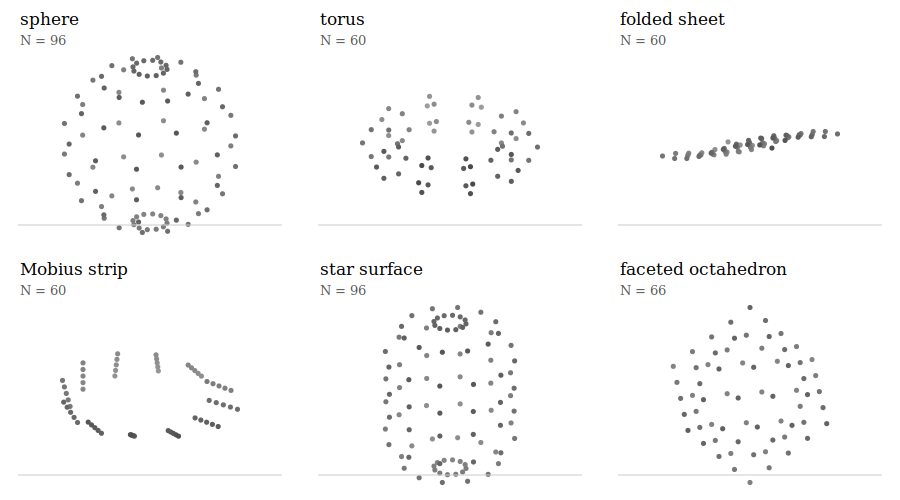

In [7]:
def project(point, yaw=0.68, pitch=0.48):
    x, y, z = point
    cy, sy = math.cos(yaw), math.sin(yaw)
    cp, sp = math.cos(pitch), math.sin(pitch)
    x1, y1 = cy * x - sy * y, sy * x + cy * y
    return x1, cp * z - sp * y1, sp * z + cp * y1

def gallery_svg(catalog):
    panel_w, panel_h, columns = 300, 250, 3
    rows = math.ceil(len(catalog) / columns)
    parts = [
        f"<svg xmlns='http://www.w3.org/2000/svg' width='{columns * panel_w}' height='{rows * panel_h}' viewBox='0 0 {columns * panel_w} {rows * panel_h}'>",
        "<rect width='100%' height='100%' fill='white'/>",
    ]
    for index, (name, (points, _weights)) in enumerate(catalog):
        ox, oy = (index % columns) * panel_w, (index // columns) * panel_h
        projected = [project(point) for point in points]
        xs, ys = [p[0] for p in projected], [p[1] for p in projected]
        span = max(max(xs) - min(xs), max(ys) - min(ys), 1e-12)
        scale = 175.0 / span
        cx, cy = 0.5 * (max(xs) + min(xs)), 0.5 * (max(ys) + min(ys))
        parts.append(f"<text x='{ox + 20}' y='{oy + 25}' font-family='serif' font-size='17'>{html.escape(name)}</text>")
        parts.append(f"<text x='{ox + 20}' y='{oy + 45}' font-family='serif' font-size='13' fill='#555'>N = {len(points)}</text>")
        for px, py, depth in sorted(projected, key=lambda item: item[2]):
            sx = ox + panel_w / 2 + scale * (px - cx)
            sy2 = oy + 145 - scale * (py - cy)
            shade = max(40, min(190, int(115 - 28 * depth)))
            parts.append(f"<circle cx='{sx:.2f}' cy='{sy2:.2f}' r='2.6' fill='rgb({shade},{shade},{shade})'/>")
        parts.append(f"<line x1='{ox + 18}' y1='{oy + 225}' x2='{ox + 282}' y2='{oy + 225}' stroke='#ccc'/>")
    parts.append("</svg>")
    return "".join(parts)

catalog = [
    ("sphere", sphere(8, 12)),
    ("torus", torus()),
    ("folded sheet", folded_sheet()),
    ("Mobius strip", mobius()),
    ("star surface", star_surface()),
    ("faceted octahedron", faceted_octahedron()),
]
display(SVG(gallery_svg(catalog)))

## 12. Head-to-head discrete audit

The next cell compiles both $p=2$ and $p=3$ operators for every shape.
The reference is an isolated streamed $O(N^2)$ pair sum from the testing
package.  It is never called by `ProductionRieszQJet` and is not a
production fallback.

The table reports the observed relative error and the analytic compression
bound.  An observed error near floating-point roundoff does not turn the
tail bound into an equality; the bound is deliberately conservative.

In [8]:
def relative_l2(reference, candidate):
    numerator = sum(abs(complex(a) - complex(b)) ** 2 for a, b in zip(reference, candidate, strict=True))
    denominator = sum(abs(complex(value)) ** 2 for value in reference)
    return math.sqrt(numerator / max(denominator, 1e-300))

audit_rows = []
compiled = {}
for name, (points, weights) in catalog:
    values = field(points)
    for power in (2.0, 3.0):
        start = time.perf_counter()
        qjet = ProductionRieszQJet(
            points, weights, kernel_power=power,
            tolerance=3e-13, maximum_order=16, leaf_size=4,
        )
        compile_ms = 1000.0 * (time.perf_counter() - start)
        start = time.perf_counter()
        candidate = qjet.apply(values)
        apply_ms = 1000.0 * (time.perf_counter() - start)
        reference = reference_weighted_distance_graph(points, weights, values, power)
        error = relative_l2(reference, candidate)
        actual_inf = max(abs(complex(a) - complex(b)) for a, b in zip(reference, candidate, strict=True))
        bound = qjet.compression_inf_bound(values)
        roundoff = 5e-13 * max(1.0, max(abs(complex(value)) for value in reference))
        stats = qjet.stats()
        assert actual_inf <= bound + roundoff
        assert error < 5e-13
        assert stats["hard_no_quadratic_contract"]
        assert not stats["quadratic_fallback"]
        assert not stats["stored_dense_operator_matrix"]
        assert stats["pair_partition_residual"] == 0
        compiled[(name, power)] = qjet
        audit_rows.append([
            name, int(power), len(points), fmt(error), fmt(bound),
            f"{100.0 * stats['analytic_pair_fraction']:.1f}%",
            stats["maximum_block_order"], fmt(compile_ms), fmt(apply_ms),
        ])

show_table(
    ["shape", "p", "N", "relative error", "compression bound", "analytic pairs", "max order", "compile ms", "apply ms"],
    audit_rows,
)

shape,p,N,relative error,compression bound,analytic pairs,max order,compile ms,apply ms
sphere,2,96,6.772e-17,3.358e-14,28.4%,16,511.071,509.960
sphere,3,96,9.924e-17,1.343e-14,26.8%,16,524.127,515.593
torus,2,60,1.101e-16,1.018e-13,10.1%,16,272.023,218.577
torus,3,60,1.055e-16,1.384e-14,2.5%,16,266.170,200.935
folded sheet,2,60,1.136e-16,2.830e-14,12.2%,16,276.859,219.395
folded sheet,3,60,7.092e-17,1.543e-14,9.9%,16,278.074,222.372
Mobius strip,2,60,1.947e-16,5.011e-14,45.0%,16,316.577,252.104
Mobius strip,3,60,1.050e-16,3.560e-14,44.1%,16,299.457,263.198
star surface,2,96,5.994e-17,3.457e-15,9.5%,16,540.938,466.568
star surface,3,96,6.581e-17,2.196e-15,5.5%,16,521.167,440.019


In [9]:
representative = compiled[("torus", 3.0)]
stats = representative.stats()
contract_rows = [
    ["method", stats["method"]],
    ["compile complexity", stats["compile_complexity"]],
    ["apply complexity", stats["apply_complexity"]],
    ["storage complexity", stats["storage_complexity"]],
    ["tree nodes", stats["tree_nodes"]],
    ["analytic blocks", stats["analytic_blocks"]],
    ["exact terminal pairs", stats["near_field_pairs"]],
    ["persistent moment entries", stats["persistent_moment_entries"]],
    ["adaptive rank", stats["adaptive_rank"]],
    ["temporary pair table entries", stats["temporary_pair_table_entries"]],
    ["dense distance matrix", stats["stored_dense_distance_matrix"]],
    ["dense operator matrix", stats["stored_dense_operator_matrix"]],
    ["quadratic fallback", stats["quadratic_fallback"]],
]
show_table(["production contract", "value"], contract_rows)

production contract,value
method,fixed_order_symmetric_gegenbauer_riesz_wspd
compile complexity,O(N log^2 N) for fixed order in 3D
apply complexity,O(N log N) for fixed order in 3D
storage complexity,O(N) for fixed order in 3D
tree nodes,31
analytic blocks,4
exact terminal pairs,1725
persistent moment entries,30039
adaptive rank,0
temporary pair table entries,0


## 13. Polyhedral edges: Mellin-Kondrat'ev repayment

The smooth WSPD graph still evaluates the discrete operator on a
polyhedral point set.  Continuum quadrature near an edge additionally
inherits the wedge singular exponent.  For a Dirichlet wedge with opening
angle $α$, separation of variables gives

$$
u(r,\theta)=r^\lambda\sin(\lambda\theta),
\qquad \lambda_m=\frac{m\pi}{\alpha}.
\tag{13.1}
$$

This is immediate from

$$
Δ(r^\lambda\psi(\theta))
=r^{\lambda-2}(\psi''+\lambda^2\psi)
$$

and the two Dirichlet endpoint conditions.
Flux therefore contains powers $r^{\lambda-1}(\log r)^q$.

For a shifted grid $r_k=h(k+β)$, Euler-Maclaurin/Hurwitz continuation
gives the leading midpoint defect

$$
h^\nu\zeta(1-\nu,\beta),
\tag{13.2}
$$

and differentiation in $ν$ supplies the logarithmic rungs.  A repayment
subtracts this defect.  Four amplitude coefficients form one fixed
three-jet, so the cost is $O(1)$ per retained edge or vertex channel and
does not force mesh refinement.

In [10]:
pencils = [
    ("convex cube edge", EdgeMellinPencil(0.5 * PI)),
    ("flat seam", EdgeMellinPencil(PI)),
    ("reentrant Fichera edge", EdgeMellinPencil(1.5 * PI)),
]
pencil_rows = [[name, fmt(pencil.opening_angle / PI), fmt(pencil.exponent)] for name, pencil in pencils]
show_table(["wedge", "opening / pi", "first exponent lambda"], pencil_rows)

channel = MellinThreeJetChannel(
    pencils[-1][1],
    coefficients=(1.0, 0.2, -0.03, 0.004),
    phase=0.5,
    label="fichera_edge",
)
repayment = MellinKondratievRepayment((channel,)).repay(1.0, step=1.0 / 64.0)
show_table(
    ["corner quantity", "value"],
    [
        ["correction", repayment.correction],
        ["Hurwitz evaluator remainder estimate", fmt(repayment.ledger.residual_norm)],
        ["stored coefficients", repayment.stats["stored_real_or_complex_coefficients"]],
        ["apply complexity", repayment.stats["apply_complexity"]],
        ["dense corner matrix", repayment.stats["stored_dense_matrix"]],
        ["full continuum corner certificate", repayment.stats["full_corner_error_certificate"]],
    ],
)
assert repayment.stats["apply_complexity"] == "O(number of retained corner channels)"
assert repayment.stats["stored_dense_matrix"] is False

wedge,opening / pi,first exponent lambda
convex cube edge,0.500,2.000
flat seam,1.000,1.000
reentrant Fichera edge,1.500,0.667


corner quantity,value
correction,0.015801089021834924
Hurwitz evaluator remainder estimate,3.821e-28
stored coefficients,4
apply complexity,O(number of retained corner channels)
dense corner matrix,False
full continuum corner certificate,False


The final row above is deliberately `False`.  The reported remainder
certifies the Hurwitz evaluator.  A complete continuum corner certificate
also requires a bound on the supplied amplitude-jet remainder and on the
smooth partition-of-unity quadrature.  The notebook does not replace that
missing analytic assumption with a self-consistency claim.

## 14. Repository-wide campaign evidence

The committed campaign covers axisymmetric surfaces, curved conic and
aircraft surfaces, refined polyhedra, a folded sheet, and a Möbius strip.
The exponents below are measured finite-range timing fits.  They support
the implementation audit but are not the proof of (10.1).

In [11]:
campaign_path = ROOT / "outputs" / "production_3d_shape_campaign" / "summary.json"
campaign = json.loads(campaign_path.read_text(encoding="utf-8"))
fit_rows = []
for family, values in campaign["scaling_fits"].items():
    fit_rows.append([
        family,
        fmt(values["compile"]),
        fmt(values["apply"]),
        "not run" if values["reference"] is None else fmt(values["reference"]),
    ])
show_table(["family", "compile exponent", "apply exponent", "direct reference exponent"], fit_rows)
show_table(
    ["accuracy family", "maximum relative error"],
    [[name, fmt(value)] for name, value in campaign["maximum_errors"].items()],
)
assert campaign["gates"]["passed"] is True
assert campaign["universal_hard_no_quadratic_contract"] is True

family,compile exponent,apply exponent,direct reference exponent
axisymmetric_golden,1.892,1.416,2.038
curved_conic_production_wspd,1.739,1.664,not run
polyhedral_hierarchy,1.399,1.452,1.979


accuracy family,maximum relative error
axisymmetric,6.222e-14
conic,5.277e-15
polyhedral,3.084e-14
unstructured_curved,3.427e-15


## 15. Extended rigorous validation

The tutorial audit above is supplemented by a fresh strict campaign over
16 geometries and point configurations.  Each geometry is compiled for
both (p=2) and (p=3), and each operator is checked on three independent
fields against the isolated compensated pair stream.  The suite includes
smooth genus-zero and genus-one surfaces, an open folded sheet, a
nonorientable Möbius strip, a faceted polyhedron, bent/twisted/periodic
conic atlases, an airplane with wings and tail, a car body with wheels,
a suspension bridge with towers and cables, a close double sheet, and a
five-decade multiscale cloud.

Every row also checks the analytic compression bound, constant nullspace,
weighted adjoint identity, nonnegative energy, exact pair partition, work
budgets, fixed rank, and absence of dense storage or fallback.  Separate
tests apply translation, rotation, node permutation, and area-aware
scaling.

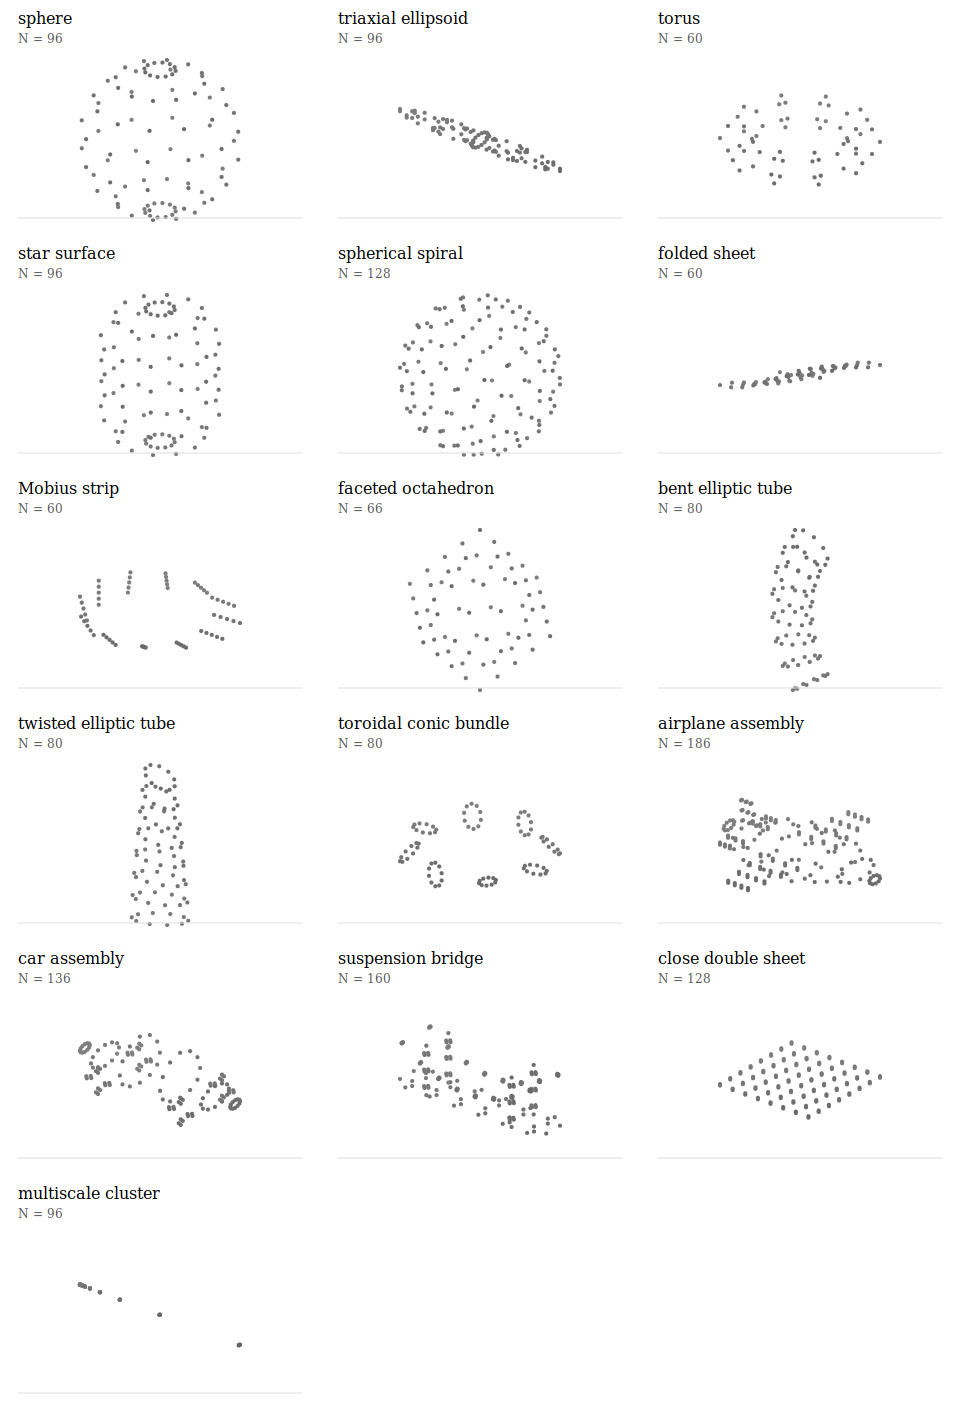

In [12]:
extended_dir = ROOT / "outputs" / "production_3d_qjet_html"
extended = json.loads((extended_dir / "validation_summary.json").read_text(encoding="utf-8"))
display(SVG(filename=str(extended_dir / "extended_shape_gallery.svg")))

In [13]:
extended_rows = []
for row in extended["cases"]:
    extended_rows.append([
        row["shape"], row["category"], row["kernel_power"], row["nodes"],
        row["fields"], fmt(row["maximum_relative_error"]),
        fmt(row["maximum_certificate_ratio"]), fmt(row["adjoint_residual"]),
        f"{100.0 * row['analytic_pair_fraction']:.1f}%",
        "PASS" if row["passed"] else "FAIL",
    ])
show_table(
    ["shape", "class", "p", "N", "fields", "max rel. error", "error / bound", "adjoint residual", "analytic pairs", "gate"],
    extended_rows,
)

shape,class,p,N,fields,max rel. error,error / bound,adjoint residual,analytic pairs,gate
sphere,closed smooth genus 0,2,96,3,6.690e-17,6.947e-05,1.110e-16,28.4%,PASS
sphere,closed smooth genus 0,3,96,3,8.808e-17,7.867e-05,2.220e-16,26.8%,PASS
triaxial ellipsoid,high aspect smooth,2,96,3,3.455e-16,3.452e-04,1.665e-16,68.5%,PASS
triaxial ellipsoid,high aspect smooth,3,96,3,1.277e-16,7.599e-05,2.359e-16,64.1%,PASS
torus,closed smooth genus 1,2,60,3,1.059e-16,1.527e-04,1.221e-15,10.1%,PASS
torus,closed smooth genus 1,3,60,3,8.470e-17,5.949e-05,1.110e-16,2.5%,PASS
star surface,nonconvex smooth,2,96,3,5.030e-17,5.215e-05,0,9.5%,PASS
star surface,nonconvex smooth,3,96,3,7.141e-17,8.691e-05,1.110e-16,5.5%,PASS
spherical spiral,unstructured point surface,2,128,3,4.592e-17,6.793e-05,4.441e-16,1.2%,PASS
spherical spiral,unstructured point surface,3,128,3,6.128e-17,9.465e-05,1.110e-16,0.0%,PASS


In [14]:
show_table(
    ["transformation", "p", "relative residual", "gate", "status"],
    [[
        row["transformation"], row["kernel_power"],
        fmt(row["relative_residual"]), fmt(row["gate"]),
        "PASS" if row["passed"] else "FAIL",
    ] for row in extended["transformations"]],
)
show_table(
    ["extended validation quantity", "value"],
    [
        ["geometries", extended["shape_count"]],
        ["operator configurations", extended["case_count"]],
        ["field comparisons", extended["field_comparisons"]],
        ["maximum ordinary-surface error", fmt(extended["maximum_standard_relative_error"])],
        ["maximum close/multiscale stress error", fmt(extended["maximum_stress_relative_error"])],
        ["maximum error / certified allowance", fmt(extended["maximum_certificate_ratio"])],
        ["maximum weighted-adjoint residual", fmt(extended["maximum_adjoint_residual"])],
        ["maximum transformation residual", fmt(extended["maximum_transformation_residual"])],
        ["dense matrix stored", not extended["no_dense_matrix"]],
        ["quadratic fallback", not extended["no_quadratic_fallback"]],
        ["overall gate", "PASS" if extended["gates"]["passed"] else "FAIL"],
    ],
)
assert extended["gates"]["passed"] is True

transformation,p,relative residual,gate,status
translation,2,4.835e-16,2.000e-12,PASS
rotation,2,2.565e-16,2.000e-12,PASS
scale,2,1.592e-16,2.000e-12,PASS
permutation,2,1.548e-16,2.000e-12,PASS
translation,3,1.785e-15,2.000e-12,PASS
rotation,3,7.448e-16,2.000e-12,PASS
scale,3,4.000e-16,2.000e-12,PASS
permutation,3,3.326e-17,2.000e-12,PASS


extended validation quantity,value
geometries,16
operator configurations,32
field comparisons,96
maximum ordinary-surface error,5.901e-16
maximum close/multiscale stress error,2.078e-13
maximum error / certified allowance,7.709e-04
maximum weighted-adjoint residual,7.956e-12
maximum transformation residual,1.785e-15
dense matrix stored,False
quadratic fallback,False


## 16. What has and has not been proved

**Established analytically**

- the discrete nullspace, weighted self-adjointness, and energy identity;
- the exact scale law $a^{2-p}$;
- the three-dimensional Laplacian trace identity for the log discriminant;
- the $1/(2\pi)$ normalization of the inverse-cube tangent-plane symbol;
- exact unordered-pair partition, convergent Gegenbauer blocks, and the
  rowwise compression bound;
- the fail-closed near-linear production contract for returned objects.

**Established numerically in this notebook**

- agreement with an isolated discrete pair stream over 16 geometries,
  32 operator configurations, and 96 independent field comparisons;
- exact constant annihilation and weighted adjoint symmetry to roundoff;
- no stored dense matrix, pair table, adaptive rank, or fallback path.

**Not inferred from those discrete tests**

- a complete DtN operator equality including all curvature terms;
- continuum convergence at a polyhedral edge without an amplitude-remainder
  estimate;
- a universal small-$N$ speed advantage over a direct pair loop.

The practical conclusion is narrower and useful: the inverse-distance
surface graph and its DtN principal channel can be evaluated by fixed
geometric jets with certified compression, linear persistent storage, and
a production path that never silently becomes quadratic.